## Selezionare particelle del Modello Standard con particolari proprietà

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as img
import pandas as pd
import sys

def plot_particles(sel, selval) :

    particles = {'electron','muon','tau','nu_e','nu_mu','nu_tau',
             'uquark','dquark','squark','cquark','bquark','tquark',
             'wboson','zboson','gluon','photon','higgs'} 

    myimages = {}
    for particle in particles:
        myimages[particle] = './sm_particles/'+particle+'.jpg'    

    particle_data = {    # charge, spin, generation, type
        'electron' : ['-1','1/2','1','l'],
        'muon' : ['-1','1/2','2','l'],
        'tau' : ['-1','1/2','3','l'],
        'nu_e' : ['0','1/2','1','l'],
        'nu_mu' : ['0','1/2','2','l'],
        'nu_tau' : ['0','1/2','3','l'],
        'uquark' : ['2/3','1/2','1','q'],
        'cquark' : ['2/3','1/2','2','q'],
        'tquark' : ['2/3','1/2','3','q'],
        'dquark' : ['-1/3','1/2','1','q'],
        'squark' : ['-1/3','1/2','2','q'],
        'bquark' : ['-1/3','1/2','3','q'],
        'photon' : ['0','1','0','wb'],
        'gluon' :  ['0','1','0','sb'],
        'wboson' : ['1','1','0','wb'],
        'zboson' : ['0','1','0','wb'],
        'higgs' : ['0','0','0','hb']
    }

    pdata = pd.DataFrame(particle_data, index = ['charge','spin','generation','type'])
    pdata = pdata.transpose()

    if (sel == 'charge') :
        possible_selvals = [selval, '-' + selval, selval[1:]]
    elif (sel == 'type' and selval == 'b') :
        possible_selvals = ['wb','sb','hb']
    else:
        possible_selvals = [selval]
    
    sel_pdata = pdata[ pdata[sel].isin(possible_selvals) ] 

    figure, axes_list = plt.subplots(ncols=3,nrows=(len(sel_pdata.index) + 2) // 3)

    for axes in axes_list.ravel():
        axes.get_xaxis().set_visible(False)
        axes.get_yaxis().set_visible(False)

    for axes, selparticle in zip(axes_list.ravel(), range(len(sel_pdata.index)) ): 
        image_name = myimages[ sel_pdata.index[selparticle] ]
        image = img.imread(image_name)
        axes.imshow(image)

    figure.tight_layout()

    plt.show()

In [28]:
if __name__ == "__main__" :
    try :
        plot_particles(sys.argv[1], sys.argv[2])
    except :
        print('You need to provide arguments \n Argument 1 is selection (charge, spin, generation, or type) \n Argument 2 is selection value')

You need to provide arguments 
 Argument 1 is selection (charge, spin, generation, or type) 
 Argument 2 is selection value


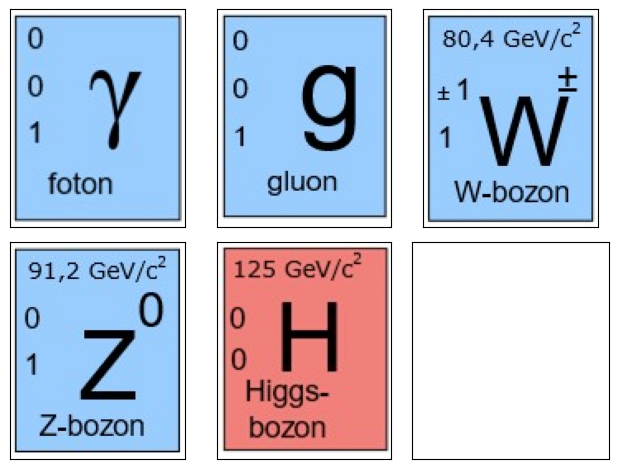

In [30]:
if __name__ == "__main__" :
    try :
        plot_particles('generation', '0')
    except :
        print('You need to provide arguments \n Argument 1 is selection (charge, spin, generation, or type) \n Argument 2 is selection value')